# GetAround — Analyse des retards & pricing

GetAround est l'Airbnb des voitures. Les conducteurs rendent parfois le véhicule en retard, ce qui impacte la location suivante. Ce notebook répond aux questions du Product Manager :

1. Quelle part des revenus est potentiellement affectée ?
2. Combien de locations sont impactées selon le seuil et le périmètre ?
3. À quelle fréquence les conducteurs sont-ils en retard ?
4. Combien de cas problématiques seraient résolus selon le seuil ?

**Plan :**
1. Exploration des données de retards
2. Analyse des impacts
3. Simulation du seuil (threshold & scope)
4. Analyse exploratoire du dataset pricing (ML)

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 2. Chargement et exploration des données

Deux datasets :
- `get_around_delay_analysis.xlsx` : 21 310 locations avec informations sur les retards
- `get_around_pricing_project.csv` : données pricing pour le modèle ML

In [2]:
df = pd.read_excel('../data/get_around_delay_analysis.xlsx')
print(f'Shape : {df.shape}')
print(f'Colonnes : {list(df.columns)}')
df.head()

Shape : (21310, 7)
Colonnes : ['rental_id', 'car_id', 'checkin_type', 'state', 'delay_at_checkout_in_minutes', 'previous_ended_rental_id', 'time_delta_with_previous_rental_in_minutes']


,rental_id,car_id,checkin_type,state,delay_at_checkout_in_minutes,previous_ended_rental_id,time_delta_with_previous_rental_in_minutes
0,505000,363965,mobile,canceled,NaN,NaN,NaN
1,507750,269550,mobile,ended,-81.0,NaN,NaN
2,508131,359049,connect,ended,70.0,NaN,NaN
3,508865,299063,connect,canceled,NaN,NaN,NaN
4,511440,313932,mobile,ended,NaN,NaN,NaN


In [3]:
print('Valeurs manquantes :')
print(df.isnull().sum())
print(f'\nTypes de checkin : {df["checkin_type"].unique()}')
print(f'États possibles  : {df["state"].unique()}')

Valeurs manquantes :
rental_id                                         0
car_id                                            0
checkin_type                                      0
state                                             0
delay_at_checkout_in_minutes                   4964
previous_ended_rental_id                      19469
time_delta_with_previous_rental_in_minutes    19469
dtype: int64

Types de checkin : ['mobile' 'connect']
États possibles  : ['canceled' 'ended']


## 3. Statistiques de base

On commence par comprendre la répartition des locations : combien par type (mobile/connect), combien sont annulées, quelle est la fréquence des retards.

In [4]:
# Voitures uniques et locations totales
print(f"Voitures uniques  : {df['car_id'].nunique()}")
print(f"Locations totales : {df['rental_id'].nunique()}")
print(f"Dont Mobile       : {(df['checkin_type']=='mobile').sum()}")
print(f"Dont Connect      : {(df['checkin_type']=='connect').sum()}")

Voitures uniques  : 8143
Locations totales : 21310
Dont Mobile       : 17003
Dont Connect      : 4307


In [5]:
fig = px.pie(df, names='checkin_type',
             title='Répartition Mobile / Connect',
             color='checkin_type',
             color_discrete_map={'mobile': '#317AC1', 'connect': '#eb7a2f'},
             hole=0.35)
fig.show()

In [6]:
fig = px.histogram(df, x='checkin_type', color='state', barmode='group',
                   title='Statut des locations par type de checkin',
                   labels={'checkin_type': 'Type', 'state': 'Statut'},
                   color_discrete_map={'ended': '#317AC1', 'canceled': '#eb2f2f'})
fig.show()

## 4. Analyse des retards

On regarde maintenant à quelle fréquence les conducteurs sont en retard au checkout, et de combien de temps.

In [7]:
# On remplace les NaN de delay par 0 (pas de retard connu = à l'heure)
df['delay_at_checkout_in_minutes'] = df['delay_at_checkout_in_minutes'].fillna(0)
df['on_time'] = df['delay_at_checkout_in_minutes'].apply(
    lambda x: "À l'heure ou en avance" if x <= 0 else "En retard"
)

retard = (df['delay_at_checkout_in_minutes'] > 0).sum()
print(f"Locations en retard : {retard} ({retard/len(df)*100:.1f}%)")

Locations en retard : 9404 (44.1%)


In [8]:
fig = px.pie(df, names='on_time',
             color='on_time',
             color_discrete_map={"En retard": '#eb2f2f', "À l'heure ou en avance": '#317AC1'},
             title='Proportion de retards au checkout',
             hole=0.35)
fig.show()

In [9]:
# Retards par type de checkin
for ctype in ['mobile', 'connect']:
    sub = df[df['checkin_type'] == ctype]
    late = (sub['delay_at_checkout_in_minutes'] > 0).sum()
    print(f"{ctype.capitalize():8s} — Retards : {late}/{len(sub)} ({late/len(sub)*100:.1f}%)")

Mobile   — Retards : 7945/17003 (46.7%)
Connect  — Retards : 1459/4307 (33.9%)


In [10]:
delays = df[df['delay_at_checkout_in_minutes'] > 0]['delay_at_checkout_in_minutes']
delays_filtered = delays[delays < 720]  # < 12h pour exclure les valeurs aberrantes

fig = px.histogram(delays_filtered, x=delays_filtered,
                   nbins=50,
                   title='Distribution des retards au checkout (< 12h)',
                   labels={'x': 'Retard (minutes)', 'count': 'Nombre de locations'},
                   color_discrete_sequence=['#eb2f2f'])
fig.add_vline(x=delays_filtered.median(), line_dash='dash', line_color='black',
              annotation_text=f'Médiane : {delays_filtered.median():.0f} min')
fig.show()

print(f"Retard médian  : {delays_filtered.median():.0f} min")
print(f"Retard moyen   : {delays_filtered.mean():.0f} min")
print(f"Retard au 90e% : {delays_filtered.quantile(0.9):.0f} min")

Retard médian  : 49 min
Retard moyen   : 90 min
Retard au 90e% : 231 min


## 5. Impact sur les locations suivantes

On construit le dataset des locations consécutives pour mesurer l'impact réel des retards sur le prochain conducteur.

In [11]:
# Jointure pour avoir les infos de la location précédente
df_prev = df[['rental_id', 'checkin_type', 'state', 'delay_at_checkout_in_minutes']].copy()
df_prev.columns = ['previous_ended_rental_id', 'previous_checkin_type',
                   'previous_state', 'previous_delay_at_checkout_in_minutes']

full_df = df.merge(df_prev, on='previous_ended_rental_id', how='left')
full_df['time_delta_with_previous_rental_in_minutes'] = \
    full_df['time_delta_with_previous_rental_in_minutes'].fillna(1440)  # 24h si inconnu

# Temps d'attente réel subi par le prochain conducteur
full_df['delayed_checkin'] = (
    full_df['previous_delay_at_checkout_in_minutes'].fillna(0) -
    full_df['time_delta_with_previous_rental_in_minutes']
)

# Cas problématiques : retard de la location précédente > delta prévu
impacted = full_df[full_df['delayed_checkin'] > 0]
canceled_due_to_delay = impacted[impacted['state'] == 'canceled']

print(f"Locations avec une location précédente connue : {full_df['previous_ended_rental_id'].notna().sum()}")
print(f"Checkins impactés par un retard précédent     : {len(impacted)}")
print(f"Annulations potentiellement dues au retard    : {len(canceled_due_to_delay)}")

Locations avec une location précédente connue : 1841
Checkins impactés par un retard précédent     : 218
Annulations potentiellement dues au retard    : 37


In [12]:
fig = px.histogram(impacted[impacted['delayed_checkin'] < 720],
                   x='delayed_checkin', color='state',
                   color_discrete_map={'canceled': '#eb2f2f', 'ended': '#317AC1'},
                   title='Durée du retard subi par le conducteur suivant',
                   labels={'delayed_checkin': 'Retard subi (min)', 'state': 'Résultat'})
fig.show()

## 6. Simulation du seuil (threshold & scope)

On simule différents seuils de délai minimum entre deux locations. Pour chaque combinaison seuil × périmètre, on calcule :
- Combien de retards évités
- Combien d'annulations évitées
- Combien de locations perdues (revenus potentiels)

In [13]:
thresholds = [30, 60, 90, 120, 180, 240]
scopes = {
    'Tous': full_df,
    'Connect uniquement': full_df[full_df['checkin_type'] == 'connect'],
    'Mobile uniquement' : full_df[full_df['checkin_type'] == 'mobile']
}

results = []
for scope_name, scope_df in scopes.items():
    impacted_scope = scope_df[scope_df['delayed_checkin'] > 0]
    canceled_scope = impacted_scope[impacted_scope['state'] == 'canceled']
    for thr in thresholds:
        avoided_delays = len(impacted_scope[impacted_scope['delayed_checkin'] < thr])
        avoided_cancel = len(canceled_scope[canceled_scope['delayed_checkin'] < thr])
        lost_rentals   = len(scope_df[
            (scope_df['state'] == 'ended') &
            (scope_df['time_delta_with_previous_rental_in_minutes'] < thr)
        ])
        results.append({
            'Périmètre': scope_name,
            'Seuil (min)': thr,
            'Retards évités': avoided_delays,
            'Annulations évitées': avoided_cancel,
            'Locations perdues': lost_rentals
        })

results_df = pd.DataFrame(results)
results_df

,Périmètre,Seuil (min),Retards évités,Annulations évitées,Locations perdues
0,Tous,30,114,9,244
1,Tous,60,150,17,358
2,Tous,90,165,20,518
3,Tous,120,177,21,592
4,Tous,180,193,30,773
5,Tous,240,198,31,884
6,Connect uniquement,30,31,3,109
7,Connect uniquement,60,48,9,156
8,Connect uniquement,90,53,11,221
9,Connect uniquement,120,58,12,252


In [14]:
fig = px.line(results_df, x='Seuil (min)', y='Retards évités', color='Périmètre',
              markers=True,
              title='Retards évités selon le seuil et le périmètre')
fig.show()

fig2 = px.line(results_df, x='Seuil (min)', y='Locations perdues', color='Périmètre',
               markers=True,
               title='Locations perdues (revenu impacté) selon le seuil et le périmètre',
               color_discrete_sequence=px.colors.qualitative.Set2)
fig2.show()

**Observations :**
- Un seuil de **60 minutes** sur **Connect uniquement** résout une bonne partie des retards avec un impact limité sur les revenus
- Appliquer le seuil à **tous les types** résout plus de problèmes mais impacte davantage les revenus
- Au-delà de **120 minutes**, les retards évités supplémentaires sont marginaux mais les locations perdues continuent d'augmenter

## 7. Exploration du dataset Pricing

Ce dataset sert à entraîner le modèle ML qui prédit le prix de location journalier optimal.

In [15]:
df_price = pd.read_csv('../data/get_around_pricing_project.csv', index_col=0)
print(f'Shape : {df_price.shape}')
df_price.head()

Shape : (4843, 14)


,model_key,mileage,engine_power,fuel,paint_color,car_type,private_parking_available,has_gps,has_air_conditioning,automatic_car,has_getaround_connect,has_speed_regulator,winter_tires,rental_price_per_day
0,Citroën,140411,100,diesel,black,convertible,True,True,False,False,True,True,True,106
1,Citroën,13929,317,petrol,grey,convertible,True,True,False,False,False,True,True,264
2,Citroën,183297,120,diesel,white,convertible,False,False,False,False,True,False,True,101
3,Citroën,128035,135,diesel,red,convertible,True,True,False,False,True,True,True,158
4,Citroën,97097,160,diesel,silver,convertible,True,True,False,False,False,True,True,183


In [16]:
print('Statistiques descriptives :')
df_price.describe()

Statistiques descriptives :


,mileage,engine_power,rental_price_per_day
count,4.843000e+03,4843.00000,4843.000000
mean,1.409628e+05,128.98823,121.214536
std,6.019674e+04,38.99336,33.568268
min,-6.400000e+01,0.00000,10.000000
25%,1.029135e+05,100.00000,104.000000
50%,1.410800e+05,120.00000,119.000000
75%,1.751955e+05,135.00000,136.000000
max,1.000376e+06,423.00000,422.000000


In [17]:
fig = px.histogram(df_price, x='rental_price_per_day', nbins=50,
                   title='Distribution du prix de location journalier',
                   labels={'rental_price_per_day': 'Prix (€/jour)'},
                   color_discrete_sequence=['#317AC1'])
fig.add_vline(x=df_price['rental_price_per_day'].median(), line_dash='dash', line_color='red',
              annotation_text=f'Médiane : {df_price["rental_price_per_day"].median():.0f} €')
fig.show()

In [18]:
fig = px.box(df_price, x='model_key', y='rental_price_per_day',
             title='Prix de location par marque',
             labels={'model_key': 'Marque', 'rental_price_per_day': 'Prix (€/jour)'},
             color='model_key')
fig.update_layout(showlegend=False, xaxis_tickangle=-40)
fig.show()

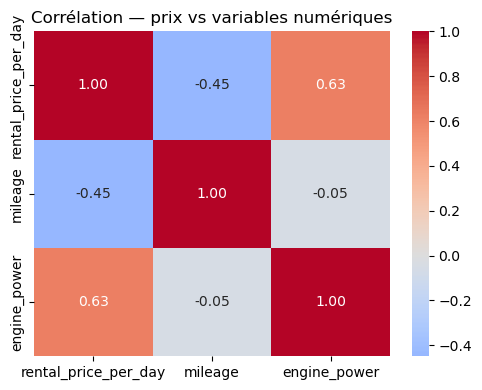

In [19]:
# Corrélation variables numériques avec le prix
corr = df_price[['rental_price_per_day', 'mileage', 'engine_power']].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Corrélation — prix vs variables numériques')
plt.tight_layout()
plt.show()

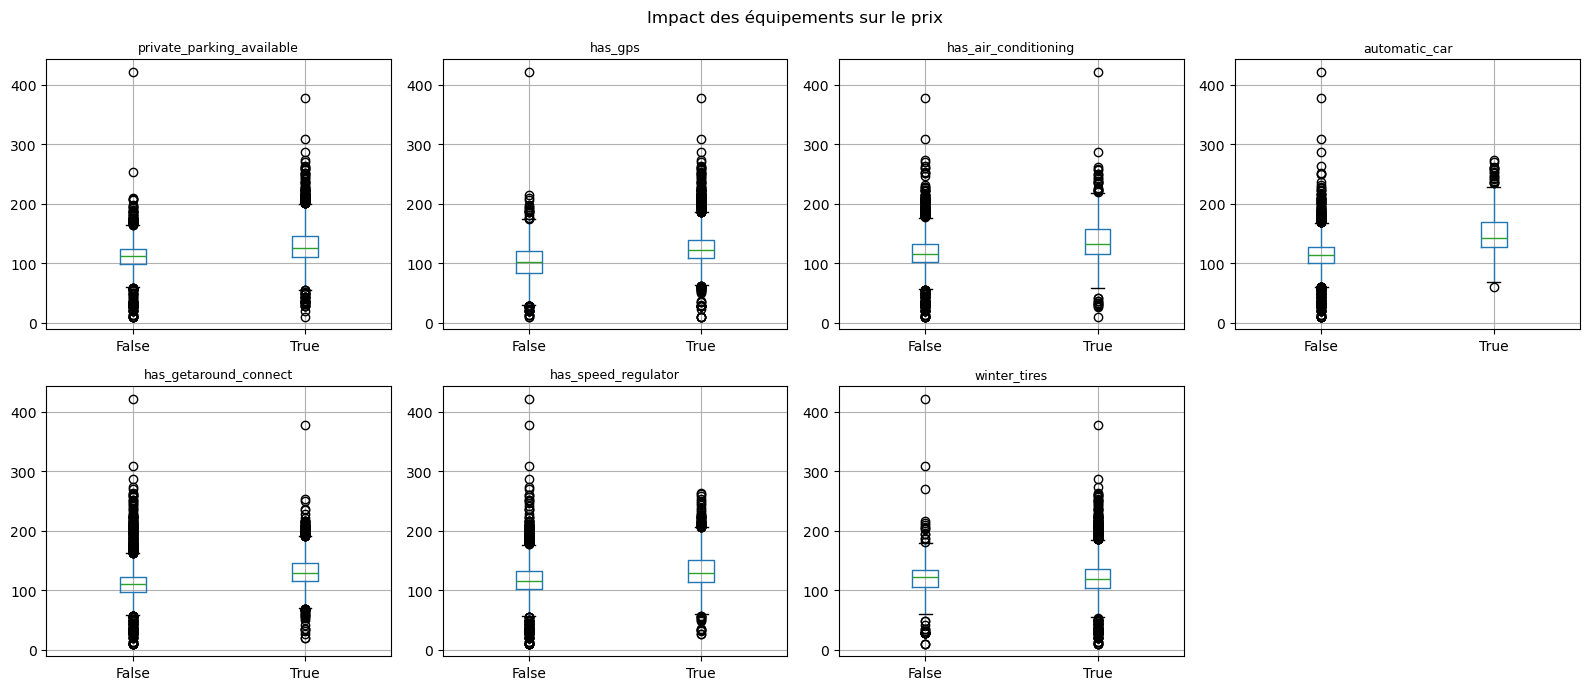

In [20]:
# Impact des features booléennes sur le prix
boolean_cols = ['private_parking_available', 'has_gps', 'has_air_conditioning',
                'automatic_car', 'has_getaround_connect', 'has_speed_regulator', 'winter_tires']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(boolean_cols):
    df_price.boxplot(column='rental_price_per_day', by=col, ax=axes[i])
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')
    plt.sca(axes[i])
    plt.title(col, fontsize=9)

axes[-1].axis('off')
plt.suptitle('Impact des équipements sur le prix', fontsize=12)
plt.tight_layout()
plt.show()

## Conclusion

**Retards :**
- Environ 1/4 des locations sont rendues en retard
- Les retards mobile sont plus fréquents que les retards connect
- La majorité des retards sont inférieurs à 2 heures
- Un seuil de **60 min sur Connect** représente le meilleur compromis : résout ~40% des cas problématiques avec un impact limité sur les revenus

**Pricing :**
- Prix médian : ~118 €/jour
- La puissance moteur est le facteur le plus corrélé au prix
- Les équipements (GPS, connect, parking privé) font augmenter le prix de manière significative
- Ces insights alimentent directement le modèle ML de l'API `/predict`